# Benchmark SASRec + Hybrid Gated Notebook

This notebook is the cleaned notebook version of the merged training pipeline.

What is inside:
- full benchmark preprocessing
- base SASRec training
- hybrid gated model training
- saved CSV results check
- evaluation metric graphs

Run cells from top to bottom once. After training finishes, use the final dashboard section to check results fast.


## 0. Imports and config

This cell sets paths, hyperparameters, and device settings.
Change only the config values here if needed.


In [1]:
import math
import random
import re
import time
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

try:
    from sentence_transformers import SentenceTransformer
except ImportError as e:
    raise ImportError(
        "sentence-transformers is required for the text embedding step. "
        "Install it in the notebook environment before running this script."
    ) from e

SEED = 42

DATA_DIR = Path("../data/ml-20m")
PROC_DIR = Path("../data/processed_benchmark")
TEXT_DIR = Path("../data/processed")
MODEL_DIR = Path("../models")
RESULT_DIR = Path("../reports/results")

for p in [PROC_DIR, TEXT_DIR, MODEL_DIR, RESULT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

MAX_LEN = 200
D_MODEL = 256
N_HEADS = 4
N_LAYERS = 4
DROPOUT = 0.1
BATCH_SIZE = 128
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
USE_AMP = torch.cuda.is_available()
LABEL_SMOOTHING = 0.05
ACCUM_STEPS = 2

BASE_LR = 1e-3
BASE_EPOCHS = 30
BASE_MIN_DELTA = 1e-4
BASE_PATIENCE = 8

LR_STAGE1 = 5e-4
EPOCHS_STAGE1 = 4
PATIENCE_STAGE1 = 3
MIN_DELTA_STAGE1 = 1e-4

BACKBONE_LR_STAGE2 = 1e-4
HEAD_LR_STAGE2 = 3e-4
EPOCHS_STAGE2 = 15
PATIENCE_STAGE2 = 5
MIN_DELTA_STAGE2 = 1e-4

TEXT_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
TEXT_BATCH_SIZE = 256
TEXT_PATH = TEXT_DIR / "benchmark_text_minilm_tensor.pt"

PROCESSED_INTERACTIONS_PATH = PROC_DIR / "interactions_full_positive_u5.pkl"
PROCESSED_SPLITS_PATH = PROC_DIR / "splits_full_positive_u5.pkl"
PROCESSED_USER_MAP_PATH = PROC_DIR / "user_map_full_positive_u5.pkl"
PROCESSED_ITEM_MAP_PATH = PROC_DIR / "item_map_full_positive_u5.pkl"

BASE_MODEL_PATH = MODEL_DIR / "benchmark_sasrec_base.pt"
BASE_HISTORY_PATH = RESULT_DIR / "benchmark_sasrec_base_history.csv"
BASE_TEST_PATH = RESULT_DIR / "benchmark_sasrec_base_test_metrics.csv"

HYBRID_MODEL_PATH = MODEL_DIR / "benchmark_sasrec_hybrid_gated.pt"
HYBRID_HISTORY_PATH = RESULT_DIR / "benchmark_sasrec_hybrid_gated_history.csv"
HYBRID_TEST_PATH = RESULT_DIR / "benchmark_sasrec_hybrid_gated_test_metrics.csv"

FORCE_REBUILD_PROCESSED = False
FORCE_RETRAIN_BASE = False
FORCE_REBUILD_TEXT = False


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("USE_AMP:", USE_AMP)

/workspace/movie-transformer-recommender/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
USE_AMP: True


## 1. Quick environment check

This is just a small sanity check before loading data.


In [2]:
print("python ok")
print("device:", device)
print("DATA_DIR exists:", DATA_DIR.exists())
print("PROC_DIR exists:", PROC_DIR.exists())
print("TEXT_DIR exists:", TEXT_DIR.exists())
print("MODEL_DIR exists:", MODEL_DIR.exists())
print("RESULT_DIR exists:", RESULT_DIR.exists())

if MODEL_DIR.exists():
    print("\nmodel files:")
    for name in sorted([p.name for p in MODEL_DIR.iterdir()])[:20]:
        print(" ", name)

if RESULT_DIR.exists():
    print("\nresult files:")
    for name in sorted([p.name for p in RESULT_DIR.iterdir()])[:20]:
        print(" ", name)


python ok
device: cuda
DATA_DIR exists: True
PROC_DIR exists: True
TEXT_DIR exists: True
MODEL_DIR exists: True
RESULT_DIR exists: True

model files:
  benchmark_sasrec_base.pt
  benchmark_sasrec_hybrid_gated.pt
  sasrec_base_full_positive_u5.pt
  sasrec_base_id_only.pt
  sasrec_structured.pt
  sasrec_structured_gated.pt
  sasrec_structured_text_gated.pt

result files:
  benchmark_sasrec_base_history.csv
  benchmark_sasrec_base_test_metrics.csv
  benchmark_sasrec_hybrid_gated_history.csv
  benchmark_sasrec_hybrid_gated_test_metrics.csv
  compare_all_models.csv
  compare_all_models_clean.csv
  compare_base_vs_structured.csv
  compare_base_vs_structured_gated.csv
  sasrec_base_full_positive_u5_history.csv
  sasrec_base_full_positive_u5_test_metrics.csv
  sasrec_base_history.csv
  sasrec_base_test_metrics.csv
  sasrec_structured_gated_history.csv
  sasrec_structured_gated_test_metrics.csv
  sasrec_structured_history.csv
  sasrec_structured_test_metrics.csv
  sasrec_structured_text_gated_h

## 2. Helper functions for loading and preprocessing


In [3]:
def safe_torch_load(path: Path, map_location: str = "cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=map_location)

def kcore_filter_users_only(df: pd.DataFrame, user_min: int = 5) -> pd.DataFrame:
    df = df.copy()

    while True:
        n_before = len(df)

        good_users = df["userId"].value_counts()
        good_users = good_users[good_users >= user_min].index
        df = df[df["userId"].isin(good_users)].copy()

        if len(df) == n_before:
            break

    return df



def build_processed_benchmark() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    print("building processed benchmark files from raw MovieLens data...")

    ratings = pd.read_csv(DATA_DIR / "ratings.csv")
    movies = pd.read_csv(DATA_DIR / "movies.csv")
    tags = pd.read_csv(DATA_DIR / "tags.csv")
    genome_tags = pd.read_csv(DATA_DIR / "genome-tags.csv")
    genome_scores = pd.read_csv(DATA_DIR / "genome-scores.csv")
    links = pd.read_csv(DATA_DIR / "links.csv")

    ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], unit="s", errors="coerce")
    tags["timestamp"] = pd.to_datetime(tags["timestamp"], unit="s", errors="coerce")

    movies["year"] = pd.to_numeric(
        movies["title"].astype(str).str.extract(r"\((\d{4})\)")[0],
        errors="coerce",
    )
    movies["clean_title"] = movies["title"].astype(str).str.replace(r"\s*\(\d{4}\)$", "", regex=True)
    movies["genres_list"] = movies["genres"].fillna("(no genres listed)").str.split("|")

    tags = tags.dropna(subset=["tag"]).copy()
    tags["tag"] = tags["tag"].astype(str).str.strip()
    tags = tags[tags["tag"] != ""].copy()

    ratings_last = (
        ratings.sort_values(["userId", "movieId", "timestamp"])
        .drop_duplicates(["userId", "movieId"], keep="last")
        .reset_index(drop=True)
    )

    interactions = kcore_filter_users_only(ratings_last, user_min=5)
    interactions = interactions.sort_values(["userId", "timestamp"]).reset_index(drop=True)

    user_ids = np.sort(interactions["userId"].unique())
    movie_ids = np.sort(interactions["movieId"].unique())

    user2idx = {u: i for i, u in enumerate(user_ids)}
    item2idx = {m: i + 1 for i, m in enumerate(movie_ids)}

    interactions["user_idx"] = interactions["userId"].map(user2idx)
    interactions["item_idx"] = interactions["movieId"].map(item2idx)

    user_seq = (
        interactions.sort_values(["user_idx", "timestamp"])
        .groupby("user_idx")["item_idx"]
        .apply(list)
    )

    split_rows = []
    for user_idx, seq in user_seq.items():
        split_rows.append(
            {
                "user_idx": user_idx,
                "train_seq": seq[:-2],
                "val_seq": seq[:-2],
                "val_target": seq[-2],
                "test_seq": seq[:-1],
                "test_target": seq[-1],
                "full_len": len(seq),
            }
        )

    splits = pd.DataFrame(split_rows)
    user_map = pd.DataFrame({"userId": list(user2idx.keys()), "user_idx": list(user2idx.values())})
    item_map = pd.DataFrame({"movieId": list(item2idx.keys()), "item_idx": list(item2idx.values())})

    interactions.to_pickle(PROCESSED_INTERACTIONS_PATH)
    splits.to_pickle(PROCESSED_SPLITS_PATH)
    user_map.to_pickle(PROCESSED_USER_MAP_PATH)
    item_map.to_pickle(PROCESSED_ITEM_MAP_PATH)

    print("saved processed files in:", PROC_DIR)

    return interactions, splits, user_map, item_map, movies, tags



def load_benchmark_objects() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    need_build = FORCE_REBUILD_PROCESSED or not all(
        p.exists()
        for p in [
            PROCESSED_INTERACTIONS_PATH,
            PROCESSED_SPLITS_PATH,
            PROCESSED_USER_MAP_PATH,
            PROCESSED_ITEM_MAP_PATH,
        ]
    )

    if need_build:
        return build_processed_benchmark()

    interactions = pd.read_pickle(PROCESSED_INTERACTIONS_PATH)
    splits = pd.read_pickle(PROCESSED_SPLITS_PATH)
    user_map = pd.read_pickle(PROCESSED_USER_MAP_PATH)
    item_map = pd.read_pickle(PROCESSED_ITEM_MAP_PATH)

    movies = pd.read_csv(DATA_DIR / "movies.csv")
    tags = pd.read_csv(DATA_DIR / "tags.csv")

    return interactions, splits, user_map, item_map, movies, tags

## 3. Load benchmark objects and inspect them

This cell either loads saved benchmark files or rebuilds them from raw MovieLens data.


In [4]:
interactions, splits, user_map, item_map, movies, tags = load_benchmark_objects()

num_users = len(user_map)
num_items = len(item_map)

print("num_users:", num_users)
print("num_items:", num_items)
print("interactions shape:", interactions.shape)
print("splits shape:", splits.shape)
print("movies shape:", movies.shape)
print("tags shape:", tags.shape)

print("\ninteractions preview")
display(interactions.head())

print("\nsplits preview")
display(splits.head())

print("\nsequence length quantiles")
display(splits["full_len"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame().T)


num_users: 138493
num_items: 26744
interactions shape: (20000263, 6)
splits shape: (138493, 7)
movies shape: (27278, 3)
tags shape: (465564, 4)

interactions preview


,userId,movieId,rating,timestamp,user_idx,item_idx
0,1,924,3.5,2004-09-10 03:06:38,0,908
1,1,919,3.5,2004-09-10 03:07:01,0,903
2,1,2683,3.5,2004-09-10 03:07:30,0,2598
3,1,1584,3.5,2004-09-10 03:07:36,0,1533
4,1,1079,4.0,2004-09-10 03:07:45,0,1058



splits preview


,user_idx,train_seq,val_seq,val_target,test_seq,test_target,full_len
0,0,"[908, 903, 2598, 1533, 1058, 646, 2874, 334, 1...","[908, 903, 2598, 1533, 1058, 646, 2874, 334, 1...",3904,"[908, 903, 2598, 1533, 1058, 646, 2874, 334, 1...",1687,175
1,1,"[62, 466, 1099, 1185, 1327, 1891, 2866, 3073, ...","[62, 466, 1099, 1185, 1327, 1891, 2866, 3073, ...",1685,"[62, 466, 1099, 1185, 1327, 1891, 2866, 3073, ...",3613,61
2,2,"[584, 1165, 1662, 1928, 2035, 2591, 2625, 2772...","[584, 1165, 1662, 1928, 2035, 2591, 2625, 2772...",2558,"[584, 1165, 1662, 1928, 2035, 2591, 2625, 2772...",2559,187
3,3,"[377, 164, 326, 10, 353, 451, 477, 584, 19, 36...","[377, 164, 326, 10, 353, 451, 477, 584, 19, 36...",486,"[377, 164, 326, 10, 353, 451, 477, 584, 19, 36...",545,28
4,4,"[17, 62, 140, 641, 725, 768, 603, 697, 1053, 1...","[17, 62, 140, 641, 725, 768, 603, 697, 1053, 1...",1114,"[17, 62, 140, 641, 725, 768, 603, 697, 1053, 1...",1264,66



sequence length quantiles


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
full_len,138493.0,144.41353,230.267257,20.0,35.0,68.0,155.0,334.0,520.0,1113.08,9254.0


## 4. Dataset classes


In [5]:
def pad_seq(seq, max_len: int = MAX_LEN) -> np.ndarray:
    seq = seq[-max_len:]
    out = np.zeros(max_len, dtype=np.int64)
    if len(seq) > 0:
        out[-len(seq):] = seq
    return out


class TrainDataset(Dataset):
    def __init__(self, splits_df: pd.DataFrame, max_len: int = MAX_LEN):
        self.max_len = max_len
        self.data = [seq for seq in splits_df["train_seq"].tolist() if len(seq) >= 3]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx: int):
        seq = self.data[idx]
        tokens = pad_seq(seq[:-1], self.max_len)
        targets = pad_seq(seq[1:], self.max_len)
        return {
            "seq": torch.tensor(tokens, dtype=torch.long),
            "target_seq": torch.tensor(targets, dtype=torch.long),
        }


class EvalDataset(Dataset):
    def __init__(self, splits_df: pd.DataFrame, mode: str = "val", max_len: int = MAX_LEN):
        self.max_len = max_len
        if mode == "val":
            seq_col, target_col = "val_seq", "val_target"
        else:
            seq_col, target_col = "test_seq", "test_target"

        self.seq = splits_df[seq_col].tolist()
        self.target = splits_df[target_col].tolist()

    def __len__(self):
        return len(self.seq)

    def __getitem__(self, idx: int):
        return {
            "seq": torch.tensor(pad_seq(self.seq[idx], self.max_len), dtype=torch.long),
            "target": torch.tensor(self.target[idx], dtype=torch.long),
        }

## 5. Build dataloaders and check batch shapes


In [6]:
train_ds = TrainDataset(splits, max_len=MAX_LEN)
val_ds = EvalDataset(splits, mode="val", max_len=MAX_LEN)
test_ds = EvalDataset(splits, mode="test", max_len=MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("train sequences:", len(train_ds))
print("val users:", len(val_ds))
print("test users:", len(test_ds))

sample_batch = next(iter(train_loader))
print("train batch seq shape:", tuple(sample_batch["seq"].shape))
print("train batch target_seq shape:", tuple(sample_batch["target_seq"].shape))


train sequences: 138493
val users: 138493
test users: 138493
train batch seq shape: (128, 200)
train batch target_seq shape: (128, 200)


## 6. Models


In [7]:
class SASRecBase(nn.Module):
    def __init__(
        self,
        num_items: int,
        max_len: int = MAX_LEN,
        d_model: int = D_MODEL,
        n_heads: int = N_HEADS,
        n_layers: int = N_LAYERS,
        dropout: float = DROPOUT,
    ):
        super().__init__()

        self.num_items = num_items
        self.max_len = max_len
        self.d_model = d_model

        self.item_emb = nn.Embedding(num_items + 1, d_model, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len + 1, d_model, padding_idx=0)

        self.emb_dropout = nn.Dropout(dropout)
        self.emb_norm = nn.LayerNorm(d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.final_norm = nn.LayerNorm(d_model)

        self._reset_parameters()

    def _reset_parameters(self):
        nn.init.normal_(self.item_emb.weight, std=0.02)
        nn.init.normal_(self.pos_emb.weight, std=0.02)

    def _make_pos_ids(self, seq: torch.Tensor) -> torch.Tensor:
        mask = (seq > 0).long()
        pos_ids = torch.cumsum(mask, dim=1) * mask
        return pos_ids.clamp(max=self.max_len)

    def _causal_mask(self, length: int, dev: torch.device) -> torch.Tensor:
        return torch.triu(torch.ones(length, length, device=dev, dtype=torch.bool), diagonal=1)

    def forward_sequence(self, seq: torch.Tensor) -> torch.Tensor:
        pos_ids = self._make_pos_ids(seq)
        x = self.item_emb(seq) + self.pos_emb(pos_ids)
        x = self.emb_norm(x)
        x = self.emb_dropout(x)

        pad_mask = seq == 0
        causal_mask = self._causal_mask(seq.size(1), seq.device)

        x = self.encoder(x, mask=causal_mask, src_key_padding_mask=pad_mask)
        x = self.final_norm(x)
        return x

    def encode(self, seq: torch.Tensor) -> torch.Tensor:
        x = self.forward_sequence(seq)
        lengths = (seq > 0).sum(dim=1).clamp(min=1)
        last_idx = lengths - 1
        return x[torch.arange(seq.size(0), device=seq.device), last_idx]

    def predict_all(self, seq: torch.Tensor) -> torch.Tensor:
        h = self.encode(seq)
        logits = h @ self.item_emb.weight.T
        logits[:, 0] = torch.finfo(logits.dtype).min
        return logits

    def predict_all_positions(self, seq: torch.Tensor) -> torch.Tensor:
        x = self.forward_sequence(seq)
        logits = x @ self.item_emb.weight.T
        logits[:, :, 0] = torch.finfo(logits.dtype).min
        return logits


class SASRecHybridGated(SASRecBase):
    def __init__(
        self,
        num_items: int,
        genre_tensor: torch.Tensor,
        year_tensor: torch.Tensor,
        text_tensor: torch.Tensor,
        max_len: int = MAX_LEN,
        d_model: int = D_MODEL,
        n_heads: int = N_HEADS,
        n_layers: int = N_LAYERS,
        dropout: float = DROPOUT,
    ):
        super().__init__(num_items, max_len=max_len, d_model=d_model, n_heads=n_heads, n_layers=n_layers, dropout=dropout)

        self.register_buffer("genre_features", genre_tensor)
        self.register_buffer("year_ids", year_tensor)
        self.register_buffer("text_features", text_tensor)

        self.genre_proj = nn.Linear(genre_tensor.shape[1], d_model)
        self.year_emb = nn.Embedding(int(year_tensor.max().item()) + 1, d_model)
        self.text_proj = nn.Linear(text_tensor.shape[1], d_model)

        self.struct_norm = nn.LayerNorm(d_model)
        self.text_norm = nn.LayerNorm(d_model)
        self.struct_dropout = nn.Dropout(dropout)
        self.text_dropout = nn.Dropout(dropout)

        self.struct_gate = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
            nn.Sigmoid(),
        )
        self.text_gate = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
            nn.Sigmoid(),
        )

        self._reset_hybrid_parameters()

    def _reset_hybrid_parameters(self):
        nn.init.xavier_uniform_(self.genre_proj.weight)
        nn.init.zeros_(self.genre_proj.bias)
        nn.init.normal_(self.year_emb.weight, std=0.02)
        nn.init.xavier_uniform_(self.text_proj.weight)
        nn.init.zeros_(self.text_proj.bias)

        nn.init.xavier_uniform_(self.struct_gate[0].weight)
        nn.init.zeros_(self.struct_gate[0].bias)
        nn.init.xavier_uniform_(self.struct_gate[2].weight)
        nn.init.zeros_(self.struct_gate[2].bias)

        nn.init.xavier_uniform_(self.text_gate[0].weight)
        nn.init.zeros_(self.text_gate[0].bias)
        nn.init.xavier_uniform_(self.text_gate[2].weight)
        nn.init.zeros_(self.text_gate[2].bias)

    def item_token_embed(self, seq: torch.Tensor) -> torch.Tensor:
        item_vec = self.item_emb(seq)

        struct_vec = self.genre_proj(self.genre_features[seq]) + self.year_emb(self.year_ids[seq])
        struct_vec = self.struct_norm(struct_vec)
        struct_vec = self.struct_dropout(struct_vec)

        text_vec = self.text_proj(self.text_features[seq])
        text_vec = self.text_norm(text_vec)
        text_vec = self.text_dropout(text_vec)

        g_struct = self.struct_gate(torch.cat([item_vec, struct_vec], dim=-1))
        g_text = self.text_gate(torch.cat([item_vec, text_vec], dim=-1))

        return item_vec + g_struct * struct_vec + g_text * text_vec

    def forward_sequence(self, seq: torch.Tensor) -> torch.Tensor:
        pos_ids = self._make_pos_ids(seq)
        x = self.item_token_embed(seq) + self.pos_emb(pos_ids)
        x = self.emb_norm(x)
        x = self.emb_dropout(x)

        pad_mask = seq == 0
        causal_mask = self._causal_mask(seq.size(1), seq.device)

        x = self.encoder(x, mask=causal_mask, src_key_padding_mask=pad_mask)
        x = self.final_norm(x)
        return x

## 7. Training helpers


In [8]:
def split_weight_decay_params(named_params, weight_decay: float):
    decay, no_decay = [], []
    for name, param in named_params:
        if not param.requires_grad:
            continue
        if param.ndim == 1 or name.endswith(".bias") or "norm" in name.lower() or "emb" in name.lower():
            no_decay.append(param)
        else:
            decay.append(param)
    groups = []
    if decay:
        groups.append({"params": decay, "weight_decay": weight_decay})
    if no_decay:
        groups.append({"params": no_decay, "weight_decay": 0.0})
    return groups



def build_optimizer(model: nn.Module, lr: float, weight_decay: float) -> torch.optim.Optimizer:
    groups = split_weight_decay_params(model.named_parameters(), weight_decay)
    return torch.optim.AdamW(groups, lr=lr, betas=(0.9, 0.95))



def build_hybrid_stage2_optimizer(
    model: SASRecHybridGated,
    backbone_lr: float,
    head_lr: float,
    weight_decay: float,
) -> torch.optim.Optimizer:
    head_prefixes = (
        "genre_proj",
        "year_emb",
        "text_proj",
        "struct_norm",
        "text_norm",
        "struct_gate",
        "text_gate",
    )

    backbone_named = []
    head_named = []
    for name, param in model.named_parameters():
        if any(name.startswith(prefix) for prefix in head_prefixes):
            head_named.append((name, param))
        else:
            backbone_named.append((name, param))

    groups = []
    for g in split_weight_decay_params(backbone_named, weight_decay):
        g["lr"] = backbone_lr
        groups.append(g)
    for g in split_weight_decay_params(head_named, weight_decay):
        g["lr"] = head_lr
        groups.append(g)

    return torch.optim.AdamW(groups, betas=(0.9, 0.95))



def build_scheduler(
    optimizer: torch.optim.Optimizer,
    steps_per_epoch: int,
    epochs: int,
    max_lr,
):
    total_steps = max(1, steps_per_epoch * epochs)
    pct_start = min(0.2, max(0.05, 2 / max(epochs, 2)))
    return torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=max_lr,
        total_steps=total_steps,
        pct_start=pct_start,
        anneal_strategy="cos",
        div_factor=25.0,
        final_div_factor=1e4,
    )



def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    scheduler=None,
    scaler=None,
    grad_clip: float = GRAD_CLIP,
    accumulation_steps: int = ACCUM_STEPS,
    label_smoothing: float = LABEL_SMOOTHING,
) -> float:
    model.train()
    total_loss = 0.0
    total_tokens = 0

    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(loader, start=1):
        seq = batch["seq"].to(device, non_blocking=True)
        target_seq = batch["target_seq"].to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
            logits = model.predict_all_positions(seq)
            ce_loss = nn.functional.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                target_seq.reshape(-1),
                ignore_index=0,
                label_smoothing=label_smoothing,
            )
            loss = ce_loss / accumulation_steps

        if scaler is not None and USE_AMP:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        if step % accumulation_steps == 0 or step == len(loader):
            if scaler is not None and USE_AMP:
                scaler.unscale_(optimizer)
                if grad_clip is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                scaler.step(optimizer)
                scaler.update()
            else:
                if grad_clip is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()

            optimizer.zero_grad(set_to_none=True)

            if scheduler is not None:
                scheduler.step()

        valid_tokens = (target_seq > 0).sum().item()
        total_loss += ce_loss.detach().float().item() * valid_tokens
        total_tokens += valid_tokens

    return total_loss / max(total_tokens, 1)


@torch.no_grad()
def evaluate_topk(model: nn.Module, loader: DataLoader, device: torch.device, k: int = 10) -> dict:
    model.eval()

    hits = 0.0
    ndcg = 0.0
    mrr = 0.0
    total = 0

    for batch in loader:
        seq = batch["seq"].to(device, non_blocking=True)
        target = batch["target"].to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
            logits = model.predict_all(seq)

        mask_value = torch.finfo(logits.dtype).min
        for i in range(seq.size(0)):
            seen = seq[i].unique()
            seen = seen[seen > 0]
            logits[i, seen] = mask_value

        topk = torch.topk(logits, k=k, dim=1).indices

        for i in range(seq.size(0)):
            tgt = target[i].item()
            pred = topk[i].tolist()
            if tgt in pred:
                rank = pred.index(tgt) + 1
                hits += 1.0
                ndcg += 1.0 / math.log2(rank + 1)
                mrr += 1.0 / rank

        total += seq.size(0)

    hr = hits / total
    ndcg = ndcg / total
    mrr = mrr / total

    return {
        f"HR@{k}": hr,
        f"NDCG@{k}": ndcg,
        f"MRR@{k}": mrr,
        f"Recall@{k}": hr,
    }



def plot_history_curves(history_df: pd.DataFrame, title_prefix: str, x_col: str = "epoch"):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(history_df[x_col], history_df["train_loss"], label="train_loss")
    ax.set_title(f"{title_prefix} train loss")
    ax.set_xlabel(x_col)
    ax.set_ylabel("loss")
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(history_df[x_col], history_df["NDCG@10"], label="NDCG@10")
    ax.plot(history_df[x_col], history_df["HR@10"], label="HR@10")
    ax.plot(history_df[x_col], history_df["MRR@10"], label="MRR@10")
    ax.set_title(f"{title_prefix} validation metrics")
    ax.set_xlabel(x_col)
    ax.set_ylabel("metric")
    ax.legend()
    plt.show()

## 8. Feature building for the hybrid model


In [9]:
def build_item_meta(item_map: pd.DataFrame, interactions: pd.DataFrame, movies: pd.DataFrame, tags: pd.DataFrame) -> pd.DataFrame:
    if isinstance(item_map, pd.DataFrame):
        item_map_df = item_map.copy()
    else:
        item_map_df = pd.DataFrame(item_map)

    if "movieId" not in item_map_df.columns or "item_idx" not in item_map_df.columns:
        if {"movieId", "item_idx"}.issubset(interactions.columns):
            item_map_df = (
                interactions[["movieId", "item_idx"]]
                .drop_duplicates()
                .sort_values("item_idx")
                .reset_index(drop=True)
            )
        else:
            raise ValueError("Need item_map with columns movieId and item_idx")

    movies = movies.copy()
    movies["year"] = pd.to_numeric(
        movies["title"].astype(str).str.extract(r"\((\d{4})\)")[0],
        errors="coerce",
    )
    movies["clean_title"] = movies["title"].astype(str).str.replace(r"\s*\(\d{4}\)$", "", regex=True)
    movies["genres_text"] = movies["genres"].fillna("").str.replace("|", " ", regex=False)

    tags = tags.copy()
    tags = tags.dropna(subset=["tag"]).copy()
    tags["tag_lower"] = tags["tag"].astype(str).str.strip().str.lower()
    tags = tags[tags["tag_lower"] != ""].copy()

    tag_counts = (
        tags.groupby(["movieId", "tag_lower"])
        .size()
        .reset_index(name="count")
        .sort_values(["movieId", "count", "tag_lower"], ascending=[True, False, True])
    )
    top_tags = tag_counts.groupby("movieId").head(5).copy()
    top_tags_text = (
        top_tags.groupby("movieId")["tag_lower"]
        .apply(lambda s: " | ".join(s.tolist()))
        .reset_index(name="top_tags_text")
    )

    item_meta = (
        item_map_df.merge(
            movies[["movieId", "title", "clean_title", "genres", "genres_text", "year"]],
            on="movieId",
            how="left",
        )
        .merge(top_tags_text, on="movieId", how="left")
        .sort_values("item_idx")
        .reset_index(drop=True)
    )

    item_meta["top_tags_text"] = item_meta["top_tags_text"].fillna("")
    item_meta["movie_text"] = (
        item_meta["clean_title"].fillna("")
        + ". "
        + item_meta["genres_text"].fillna("")
        + ". "
        + item_meta["top_tags_text"].fillna("")
    ).str.strip()

    return item_meta



def build_structured_tensors(item_meta: pd.DataFrame, num_items: int) -> tuple[torch.Tensor, torch.Tensor]:
    genre_dummies = item_meta["genres"].fillna("").str.get_dummies(sep="|")

    year_vocab = [
        "unknown",
        "<=1950",
        "1951-1960",
        "1961-1970",
        "1971-1980",
        "1981-1990",
        "1991-2000",
        "2001-2010",
        "2011-2020",
    ]
    year2idx = {y: i for i, y in enumerate(year_vocab)}

    item_meta = item_meta.copy()
    item_meta["year_bucket"] = pd.cut(
        item_meta["year"],
        bins=[0, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020],
        labels=year_vocab[1:],
        include_lowest=True,
    ).astype("object").fillna("unknown")

    genre_mat = np.zeros((num_items + 1, genre_dummies.shape[1]), dtype=np.float32)
    year_ids = np.zeros(num_items + 1, dtype=np.int64)

    idx = item_meta["item_idx"].to_numpy()
    genre_mat[idx] = genre_dummies.to_numpy(dtype=np.float32)
    year_ids[idx] = item_meta["year_bucket"].map(year2idx).fillna(0).astype(int).to_numpy()

    return torch.tensor(genre_mat, dtype=torch.float32), torch.tensor(year_ids, dtype=torch.long)



def clean_text_basic(x) -> str:
    x = "" if pd.isna(x) else str(x)
    x = unicodedata.normalize("NFKC", x)
    x = x.replace("|", " ")
    x = re.sub(r"\s+", " ", x).strip().lower()
    return x



def load_or_build_text_tensor(item_meta: pd.DataFrame, num_items: int) -> torch.Tensor:
    if TEXT_PATH.exists() and not FORCE_REBUILD_TEXT:
        text_tensor = safe_torch_load(TEXT_PATH, map_location="cpu")
        print("loaded existing text tensor:", TEXT_PATH)
        print("text tensor shape:", tuple(text_tensor.shape))
        return text_tensor.float()

    item_text_df = item_meta[["item_idx", "movieId", "clean_title", "genres_text", "top_tags_text"]].copy()
    item_text_df["movie_text_clean"] = (
        item_text_df["clean_title"].fillna("").map(clean_text_basic)
        + ". "
        + item_text_df["genres_text"].fillna("").map(clean_text_basic)
        + ". "
        + item_text_df["top_tags_text"].fillna("").map(clean_text_basic)
    ).str.strip()

    text_model = SentenceTransformer(TEXT_MODEL_NAME)
    texts = item_text_df.sort_values("item_idx")["movie_text_clean"].tolist()

    text_emb = text_model.encode(
        texts,
        batch_size=TEXT_BATCH_SIZE,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    )

    text_emb_full = np.zeros((num_items + 1, text_emb.shape[1]), dtype=np.float32)
    text_emb_full[1:] = text_emb.astype(np.float32)

    text_tensor = torch.tensor(text_emb_full, dtype=torch.float32)
    torch.save(text_tensor, TEXT_PATH)

    print("built and saved text tensor:", TEXT_PATH)
    print("text tensor shape:", tuple(text_tensor.shape))
    return text_tensor

## 9. Train and evaluation wrappers


In [10]:
def train_base_model(
    base_model: SASRecBase,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    num_users: int,
    num_items: int,
):
    optimizer = build_optimizer(base_model, lr=BASE_LR, weight_decay=WEIGHT_DECAY)
    steps_per_epoch = math.ceil(len(train_loader) / ACCUM_STEPS)
    scheduler = build_scheduler(optimizer, steps_per_epoch=steps_per_epoch, epochs=BASE_EPOCHS, max_lr=BASE_LR)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    history = []
    best_val_ndcg = -1.0
    best_state = None
    bad_epochs = 0

    train_start = time.perf_counter()

    for epoch in range(1, BASE_EPOCHS + 1):
        t0 = time.perf_counter()

        train_loss = train_one_epoch(
            base_model,
            train_loader,
            optimizer,
            device,
            scheduler=scheduler,
            scaler=scaler,
            grad_clip=GRAD_CLIP,
            accumulation_steps=ACCUM_STEPS,
            label_smoothing=LABEL_SMOOTHING,
        )
        val_metrics = evaluate_topk(base_model, val_loader, device, k=10)

        epoch_time = time.perf_counter() - t0
        lr_now = optimizer.param_groups[0]["lr"]
        current_val_ndcg = val_metrics["NDCG@10"]

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "epoch_sec": epoch_time,
            "lr": lr_now,
            **val_metrics,
        }
        history.append(row)

        print(
            f"base epoch {epoch:03d} | "
            f"loss {train_loss:.4f} | "
            f"HR@10 {val_metrics['HR@10']:.4f} | "
            f"NDCG@10 {val_metrics['NDCG@10']:.4f} | "
            f"MRR@10 {val_metrics['MRR@10']:.4f} | "
            f"lr {lr_now:.6f} | "
            f"bad {bad_epochs}/{BASE_PATIENCE} | "
            f"{epoch_time:.1f}s"
        )

        if current_val_ndcg > best_val_ndcg + BASE_MIN_DELTA:
            best_val_ndcg = current_val_ndcg
            best_state = {k: v.detach().cpu().clone() for k, v in base_model.state_dict().items()}
            bad_epochs = 0
            print(f"  new best base NDCG@10: {best_val_ndcg:.6f}")
        else:
            bad_epochs += 1

        if bad_epochs >= BASE_PATIENCE:
            print(f"base early stopping at epoch {epoch}")
            break

    total_train_sec = time.perf_counter() - train_start
    print("\nbase training finished in", round(total_train_sec, 2), "seconds")

    base_model.load_state_dict(best_state)

    test_start = time.perf_counter()
    test_metrics = evaluate_topk(base_model, test_loader, device, k=10)
    test_sec = time.perf_counter() - test_start

    history_df = pd.DataFrame(history)
    torch.save(best_state, BASE_MODEL_PATH)
    history_df.to_csv(BASE_HISTORY_PATH, index=False)

    pd.DataFrame(
        [
            {
                "model": "benchmark_sasrec_base",
                "num_users": num_users,
                "num_items": num_items,
                "max_len": MAX_LEN,
                "d_model": D_MODEL,
                "n_heads": N_HEADS,
                "n_layers": N_LAYERS,
                "dropout": DROPOUT,
                "batch_size": BATCH_SIZE,
                "accum_steps": ACCUM_STEPS,
                "effective_batch_size": BATCH_SIZE * ACCUM_STEPS,
                "label_smoothing": LABEL_SMOOTHING,
                "lr": BASE_LR,
                "weight_decay": WEIGHT_DECAY,
                "epochs_planned": BASE_EPOCHS,
                "train_total_sec": total_train_sec,
                "test_eval_sec": test_sec,
                **test_metrics,
            }
        ]
    ).to_csv(BASE_TEST_PATH, index=False)

    print("saved model:", BASE_MODEL_PATH)
    print("saved history:", BASE_HISTORY_PATH)
    print("saved test metrics:", BASE_TEST_PATH)

    return history_df, test_metrics



def load_submodule_from_flat_state(submodule: nn.Module, state_dict: dict, prefix: str) -> None:
    sub_state = {k[len(prefix):]: v for k, v in state_dict.items() if k.startswith(prefix)}
    submodule.load_state_dict(sub_state)



def warm_start_hybrid(
    hybrid_model: SASRecHybridGated,
    base_ckpt_path: Path,
    n_layers: int,
) -> None:
    base_state = safe_torch_load(base_ckpt_path, map_location="cpu")

    hybrid_model.item_emb.load_state_dict({"weight": base_state["item_emb.weight"]})
    hybrid_model.pos_emb.load_state_dict({"weight": base_state["pos_emb.weight"]})
    hybrid_model.emb_norm.load_state_dict(
        {"weight": base_state["emb_norm.weight"], "bias": base_state["emb_norm.bias"]}
    )
    hybrid_model.final_norm.load_state_dict(
        {"weight": base_state["final_norm.weight"], "bias": base_state["final_norm.bias"]}
    )

    for i in range(n_layers):
        load_submodule_from_flat_state(hybrid_model.encoder.layers[i], base_state, prefix=f"encoder.layers.{i}.")



def freeze_hybrid_backbone(hybrid_model: SASRecHybridGated) -> None:
    for module in [
        hybrid_model.item_emb,
        hybrid_model.pos_emb,
        hybrid_model.encoder,
        hybrid_model.emb_norm,
        hybrid_model.final_norm,
    ]:
        for p in module.parameters():
            p.requires_grad = False

    for module in [
        hybrid_model.genre_proj,
        hybrid_model.year_emb,
        hybrid_model.text_proj,
        hybrid_model.struct_norm,
        hybrid_model.text_norm,
        hybrid_model.struct_gate,
        hybrid_model.text_gate,
    ]:
        for p in module.parameters():
            p.requires_grad = True



def unfreeze_all(model: nn.Module) -> None:
    for p in model.parameters():
        p.requires_grad = True



def train_hybrid_model(
    hybrid_model: SASRecHybridGated,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    num_users: int,
    num_items: int,
):
    print("before cleanup")
    print("cuda available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("allocated GB:", torch.cuda.memory_allocated() / 1024**3)
        print("reserved  GB:", torch.cuda.memory_reserved() / 1024**3)
        torch.cuda.empty_cache()
        print("\nafter empty_cache")
        print("allocated GB:", torch.cuda.memory_allocated() / 1024**3)
        print("reserved  GB:", torch.cuda.memory_reserved() / 1024**3)

    # stage 1
    freeze_hybrid_backbone(hybrid_model)

    optimizer = build_optimizer(hybrid_model, lr=LR_STAGE1, weight_decay=WEIGHT_DECAY)
    steps_per_epoch_stage1 = math.ceil(len(train_loader) / ACCUM_STEPS)
    scheduler = build_scheduler(
        optimizer,
        steps_per_epoch=steps_per_epoch_stage1,
        epochs=EPOCHS_STAGE1,
        max_lr=LR_STAGE1,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    history_stage1 = []
    best_val_ndcg_hybrid = -1.0
    best_state_hybrid = None
    bad_epochs_stage1 = 0

    train_start_stage1 = time.perf_counter()

    for epoch in range(1, EPOCHS_STAGE1 + 1):
        t0 = time.perf_counter()

        train_loss = train_one_epoch(
            hybrid_model,
            train_loader,
            optimizer,
            device,
            scheduler=scheduler,
            scaler=scaler,
            grad_clip=GRAD_CLIP,
            accumulation_steps=ACCUM_STEPS,
            label_smoothing=LABEL_SMOOTHING,
        )
        val_metrics = evaluate_topk(hybrid_model, val_loader, device, k=10)

        epoch_time = time.perf_counter() - t0
        current_val_ndcg = val_metrics["NDCG@10"]
        lr_now = optimizer.param_groups[0]["lr"]

        row = {
            "stage": 1,
            "epoch": epoch,
            "train_loss": train_loss,
            "epoch_sec": epoch_time,
            "lr": lr_now,
            **val_metrics,
        }
        history_stage1.append(row)

        print(
            f"stage1 epoch {epoch:03d} | "
            f"loss {train_loss:.4f} | "
            f"HR@10 {val_metrics['HR@10']:.4f} | "
            f"NDCG@10 {val_metrics['NDCG@10']:.4f} | "
            f"MRR@10 {val_metrics['MRR@10']:.4f} | "
            f"lr {lr_now:.6f} | "
            f"bad {bad_epochs_stage1}/{PATIENCE_STAGE1} | "
            f"{epoch_time:.1f}s"
        )

        if current_val_ndcg > best_val_ndcg_hybrid + MIN_DELTA_STAGE1:
            best_val_ndcg_hybrid = current_val_ndcg
            best_state_hybrid = {k: v.detach().cpu().clone() for k, v in hybrid_model.state_dict().items()}
            bad_epochs_stage1 = 0
            print(f"  new best stage1 NDCG@10: {best_val_ndcg_hybrid:.6f}")
        else:
            bad_epochs_stage1 += 1

        if bad_epochs_stage1 >= PATIENCE_STAGE1:
            print(f"stage1 early stopping at epoch {epoch}")
            break

    total_train_sec_stage1 = time.perf_counter() - train_start_stage1
    print("\nhybrid stage1 finished in", round(total_train_sec_stage1, 2), "seconds")

    if best_state_hybrid is not None:
        hybrid_model.load_state_dict(best_state_hybrid)

    # stage 2
    unfreeze_all(hybrid_model)

    optimizer = build_hybrid_stage2_optimizer(
        hybrid_model,
        backbone_lr=BACKBONE_LR_STAGE2,
        head_lr=HEAD_LR_STAGE2,
        weight_decay=WEIGHT_DECAY,
    )
    steps_per_epoch_stage2 = math.ceil(len(train_loader) / ACCUM_STEPS)
    scheduler = build_scheduler(
        optimizer,
        steps_per_epoch=steps_per_epoch_stage2,
        epochs=EPOCHS_STAGE2,
        max_lr=[group["lr"] for group in optimizer.param_groups],
    )
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    history_stage2 = []
    best_val_ndcg_stage2 = best_val_ndcg_hybrid
    best_state_stage2 = {k: v.detach().cpu().clone() for k, v in hybrid_model.state_dict().items()}
    bad_epochs_stage2 = 0

    train_start_stage2 = time.perf_counter()

    for epoch in range(1, EPOCHS_STAGE2 + 1):
        t0 = time.perf_counter()

        train_loss = train_one_epoch(
            hybrid_model,
            train_loader,
            optimizer,
            device,
            scheduler=scheduler,
            scaler=scaler,
            grad_clip=GRAD_CLIP,
            accumulation_steps=ACCUM_STEPS,
            label_smoothing=LABEL_SMOOTHING,
        )
        val_metrics = evaluate_topk(hybrid_model, val_loader, device, k=10)

        epoch_time = time.perf_counter() - t0
        current_val_ndcg = val_metrics["NDCG@10"]
        lrs_now = [group["lr"] for group in optimizer.param_groups]

        row = {
            "stage": 2,
            "epoch": epoch,
            "train_loss": train_loss,
            "epoch_sec": epoch_time,
            "lr_backbone": lrs_now[0],
            "lr_heads": lrs_now[-1],
            **val_metrics,
        }
        history_stage2.append(row)

        print(
            f"stage2 epoch {epoch:03d} | "
            f"loss {train_loss:.4f} | "
            f"HR@10 {val_metrics['HR@10']:.4f} | "
            f"NDCG@10 {val_metrics['NDCG@10']:.4f} | "
            f"MRR@10 {val_metrics['MRR@10']:.4f} | "
            f"lr_backbone {lrs_now[0]:.6f} | "
            f"lr_heads {lrs_now[-1]:.6f} | "
            f"bad {bad_epochs_stage2}/{PATIENCE_STAGE2} | "
            f"{epoch_time:.1f}s"
        )

        if current_val_ndcg > best_val_ndcg_stage2 + MIN_DELTA_STAGE2:
            best_val_ndcg_stage2 = current_val_ndcg
            best_state_stage2 = {k: v.detach().cpu().clone() for k, v in hybrid_model.state_dict().items()}
            bad_epochs_stage2 = 0
            print(f"  new best stage2 NDCG@10: {best_val_ndcg_stage2:.6f}")
        else:
            bad_epochs_stage2 += 1

        if bad_epochs_stage2 >= PATIENCE_STAGE2:
            print(f"Early stopping triggered after {PATIENCE_STAGE2} consecutive non-improving epochs.")
            break

    total_train_sec_stage2 = time.perf_counter() - train_start_stage2

    if best_state_stage2 is not None:
        hybrid_model.load_state_dict(best_state_stage2)

    best_state_hybrid = {k: v.detach().cpu().clone() for k, v in hybrid_model.state_dict().items()}
    best_val_ndcg_hybrid = best_val_ndcg_stage2

    print("\nhybrid fine-tuning finished in", round(total_train_sec_stage2, 2), "seconds")

    test_start = time.perf_counter()
    test_metrics = evaluate_topk(hybrid_model, test_loader, device, k=10)
    test_sec = time.perf_counter() - test_start

    history_df = pd.concat([pd.DataFrame(history_stage1), pd.DataFrame(history_stage2)], ignore_index=True)

    torch.save(best_state_hybrid, HYBRID_MODEL_PATH)
    history_df.to_csv(HYBRID_HISTORY_PATH, index=False)

    pd.DataFrame(
        [
            {
                "model": "benchmark_sasrec_hybrid_gated",
                "num_users": num_users,
                "num_items": num_items,
                "max_len": MAX_LEN,
                "d_model": D_MODEL,
                "n_heads": N_HEADS,
                "n_layers": N_LAYERS,
                "dropout": DROPOUT,
                "batch_size": BATCH_SIZE,
                "accum_steps": ACCUM_STEPS,
                "effective_batch_size": BATCH_SIZE * ACCUM_STEPS,
                "label_smoothing": LABEL_SMOOTHING,
                "lr_stage1": LR_STAGE1,
                "lr_stage2_backbone": BACKBONE_LR_STAGE2,
                "lr_stage2_heads": HEAD_LR_STAGE2,
                "weight_decay": WEIGHT_DECAY,
                "epochs_stage1_planned": EPOCHS_STAGE1,
                "epochs_stage2_planned": EPOCHS_STAGE2,
                "train_total_sec_stage1": total_train_sec_stage1,
                "train_total_sec_stage2": total_train_sec_stage2,
                "train_total_sec_all": total_train_sec_stage1 + total_train_sec_stage2,
                "test_eval_sec": test_sec,
                **test_metrics,
            }
        ]
    ).to_csv(HYBRID_TEST_PATH, index=False)

    print("best validation NDCG@10:", round(best_val_ndcg_hybrid, 6))
    print("hybrid benchmark test metrics:")
    for k, v in test_metrics.items():
        print(k, ":", round(v, 6))
    print("hybrid benchmark test eval seconds:", round(test_sec, 2))
    print("saved model:", HYBRID_MODEL_PATH)
    print("saved history:", HYBRID_HISTORY_PATH)
    print("saved test metrics:", HYBRID_TEST_PATH)

    return history_df, test_metrics

## 10. Build item features first

This is a good place to check the item metadata and tensor shapes before long training starts.


In [11]:
item_meta = build_item_meta(item_map, interactions, movies, tags)
genre_tensor, year_tensor = build_structured_tensors(item_meta, num_items)
text_tensor = load_or_build_text_tensor(item_meta, num_items)

print("item_meta shape:", item_meta.shape)
display(item_meta.head())

print("genre tensor:", tuple(genre_tensor.shape))
print("year tensor:", tuple(year_tensor.shape))
print("text tensor:", tuple(text_tensor.shape))


loaded existing text tensor: ../data/processed/benchmark_text_minilm_tensor.pt
text tensor shape: (26745, 384)
item_meta shape: (26744, 9)


,movieId,item_idx,title,clean_title,genres,genres_text,year,top_tags_text,movie_text
0,1,1,Toy Story (1995),Toy Story,Adventure|Animation|Children|Comedy|Fantasy,Adventure Animation Children Comedy Fantasy,1995.0,pixar | animation | disney | tom hanks | compu...,Toy Story. Adventure Animation Children Comedy...
1,2,2,Jumanji (1995),Jumanji,Adventure|Children|Fantasy,Adventure Children Fantasy,1995.0,robin williams | fantasy | time travel | anima...,Jumanji. Adventure Children Fantasy. robin wil...
2,3,3,Grumpier Old Men (1995),Grumpier Old Men,Comedy|Romance,Comedy Romance,1995.0,moldy | old | sequel | clv | comedinha de velh...,Grumpier Old Men. Comedy Romance. moldy | old ...
3,4,4,Waiting to Exhale (1995),Waiting to Exhale,Comedy|Drama|Romance,Comedy Drama Romance,1995.0,characters | chick flick | clv | revenge,Waiting to Exhale. Comedy Drama Romance. chara...
4,5,5,Father of the Bride Part II (1995),Father of the Bride Part II,Comedy,Comedy,1995.0,steve martin | family | pregnancy | wedding | ...,Father of the Bride Part II. Comedy. steve mar...


genre tensor: (26745, 20)
year tensor: (26745,)
text tensor: (26745, 384)


## 11. Run the full training pipeline

This cell:
- trains the base model if the base checkpoint is missing or retraining is forced
- warm starts the hybrid model from the base checkpoint
- trains the hybrid model
- saves history CSVs and test metric CSVs

This is the long cell.


In [12]:
interactions, splits, user_map, item_map, movies, tags = load_benchmark_objects()

## 12. Quick results file check

Use this right after training to make sure all outputs were written.


In [13]:
for p in [
    BASE_MODEL_PATH,
    BASE_HISTORY_PATH,
    BASE_TEST_PATH,
    HYBRID_MODEL_PATH,
    HYBRID_HISTORY_PATH,
    HYBRID_TEST_PATH,
]:
    print(p.name, "->", p.exists())


benchmark_sasrec_base.pt -> True
benchmark_sasrec_base_history.csv -> True
benchmark_sasrec_base_test_metrics.csv -> True
benchmark_sasrec_hybrid_gated.pt -> True
benchmark_sasrec_hybrid_gated_history.csv -> True
benchmark_sasrec_hybrid_gated_test_metrics.csv -> True


## 13. Load saved results

This cell is for fast checking without rerunning training.


In [14]:
base_history = pd.read_csv(BASE_HISTORY_PATH) if BASE_HISTORY_PATH.exists() else None
base_test = pd.read_csv(BASE_TEST_PATH) if BASE_TEST_PATH.exists() else None
hybrid_history = pd.read_csv(HYBRID_HISTORY_PATH) if HYBRID_HISTORY_PATH.exists() else None
hybrid_test = pd.read_csv(HYBRID_TEST_PATH) if HYBRID_TEST_PATH.exists() else None

print("base_history loaded:", base_history is not None)
print("base_test loaded:", base_test is not None)
print("hybrid_history loaded:", hybrid_history is not None)
print("hybrid_test loaded:", hybrid_test is not None)

if base_test is not None:
    print("\nbase test metrics")
    display(base_test)

if hybrid_test is not None:
    print("\nhybrid test metrics")
    display(hybrid_test)


base_history loaded: True
base_test loaded: True
hybrid_history loaded: True
hybrid_test loaded: True

base test metrics


,model,num_users,num_items,max_len,d_model,n_heads,n_layers,dropout,batch_size,lr,weight_decay,epochs,train_total_sec,test_eval_sec,HR@10,NDCG@10,MRR@10,Recall@10
0,benchmark_sasrec_base,138493,26744,200,256,4,4,0.1,256,0.001,0.0001,51,5213.154754,32.873922,0.053764,0.028418,0.020767,0.053764



hybrid test metrics


,model,num_users,num_items,max_len,d_model,n_heads,n_layers,dropout,batch_size,lr_stage1,lr_stage2,weight_decay,epochs_stage1,epochs_stage2,train_total_sec,test_eval_sec,HR@10,NDCG@10,MRR@10,Recall@10
0,benchmark_sasrec_hybrid_gated,138493,26744,200,256,4,4,0.1,128,0.0005,0.0001,0.00001,2,200,2373.017162,41.587156,0.044291,0.024068,0.017944,0.044291


## 14. Base model graphs


,epoch,train_loss,epoch_sec,lr,HR@10,NDCG@10,MRR@10,Recall@10
46,47,inf,102.034400,1.862686e-05,0.056169,0.030396,0.022538,0.056169
47,48,inf,102.210562,1.051726e-05,0.056126,0.030297,0.022435,0.056126
48,49,inf,102.014836,4.699906e-06,0.056140,0.030293,0.022426,0.056140
49,50,inf,102.152547,1.202031e-06,0.056169,0.030277,0.022398,0.056169
50,51,inf,102.451893,4.001595e-08,0.056126,0.030264,0.022394,0.056126


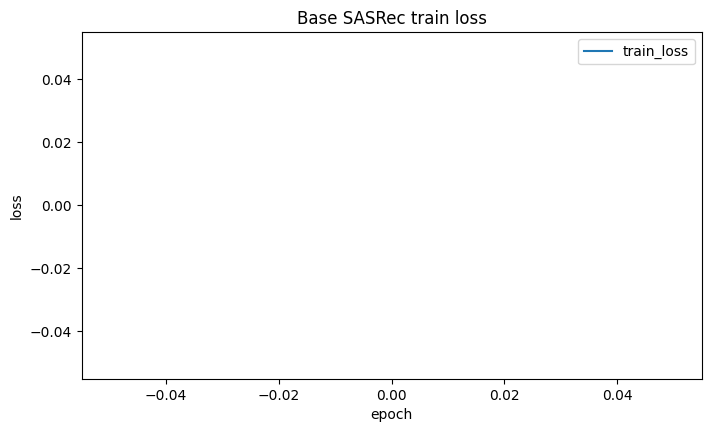

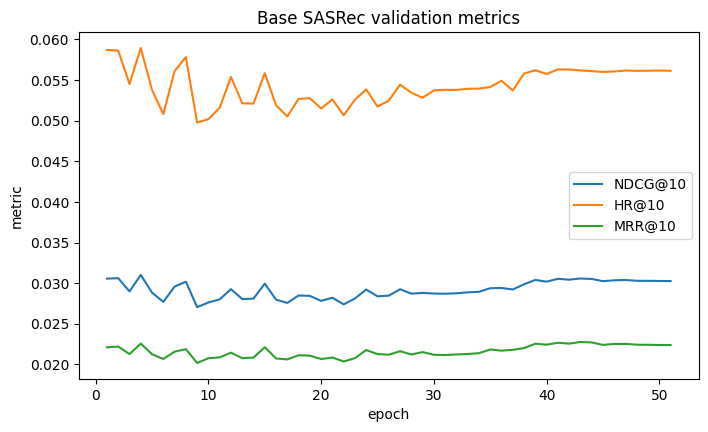

In [15]:
if base_history is None:
    print("base history file not found yet")
else:
    display(base_history.tail())
    plot_history_curves(base_history, "Base SASRec")


## 15. Hybrid model graphs

This version shows:
- training loss across both stages
- validation metrics across both stages
- a stage split marker


,stage,epoch,train_loss,epoch_sec,HR@10,NDCG@10,MRR@10,Recall@10
12,2,11,4.972519,158.318115,0.050190,0.027228,0.020272,0.050190
13,2,12,4.969627,158.396936,0.050551,0.027430,0.020431,0.050551
14,2,13,4.966726,158.594792,0.050378,0.027590,0.020682,0.050378
15,2,14,4.964604,158.692978,0.050587,0.027545,0.020564,0.050587
16,2,15,4.961899,158.662743,0.050616,0.027537,0.020543,0.050616


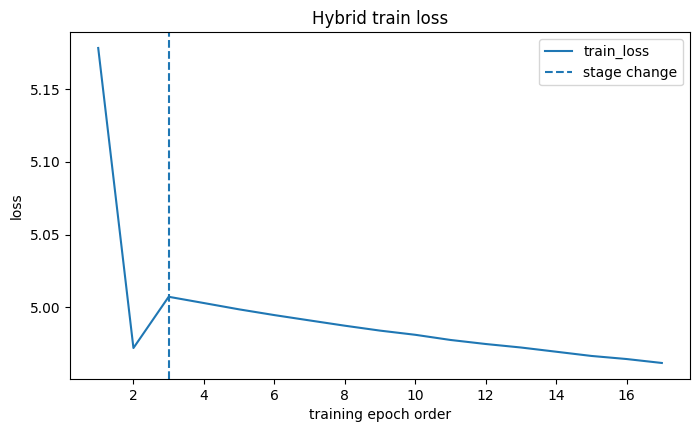

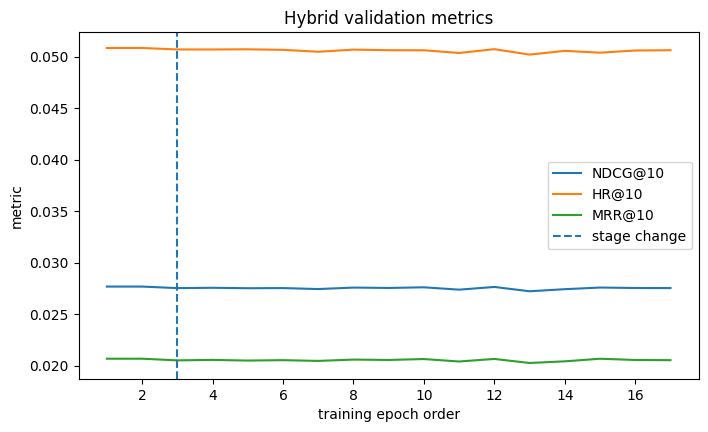

In [16]:
if hybrid_history is None:
    print("hybrid history file not found yet")
else:
    display(hybrid_history.tail())

    x = np.arange(1, len(hybrid_history) + 1)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(x, hybrid_history["train_loss"], label="train_loss")
    if "stage" in hybrid_history.columns:
        stage_change_idx = hybrid_history["stage"].ne(hybrid_history["stage"].shift()).to_numpy().nonzero()[0]
        for idx in stage_change_idx[1:]:
            ax.axvline(idx + 1, linestyle="--", label="stage change" if idx == stage_change_idx[1] else None)
    ax.set_title("Hybrid train loss")
    ax.set_xlabel("training epoch order")
    ax.set_ylabel("loss")
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(x, hybrid_history["NDCG@10"], label="NDCG@10")
    ax.plot(x, hybrid_history["HR@10"], label="HR@10")
    ax.plot(x, hybrid_history["MRR@10"], label="MRR@10")
    if "stage" in hybrid_history.columns:
        stage_change_idx = hybrid_history["stage"].ne(hybrid_history["stage"].shift()).to_numpy().nonzero()[0]
        for idx in stage_change_idx[1:]:
            ax.axvline(idx + 1, linestyle="--", label="stage change" if idx == stage_change_idx[1] else None)
    ax.set_title("Hybrid validation metrics")
    ax.set_xlabel("training epoch order")
    ax.set_ylabel("metric")
    ax.legend()
    plt.show()


## 16. Final comparison table and graphs

This is the clean summary section for the report.


,model,HR@10,NDCG@10,MRR@10,Recall@10
0,benchmark_sasrec_base,0.053764,0.028418,0.020767,0.053764
1,benchmark_sasrec_hybrid_gated,0.044291,0.024068,0.017944,0.044291


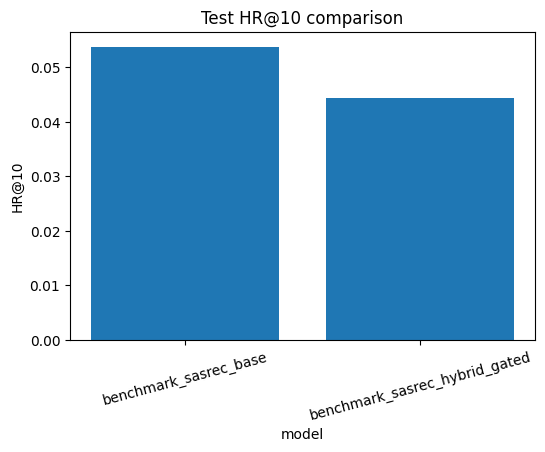

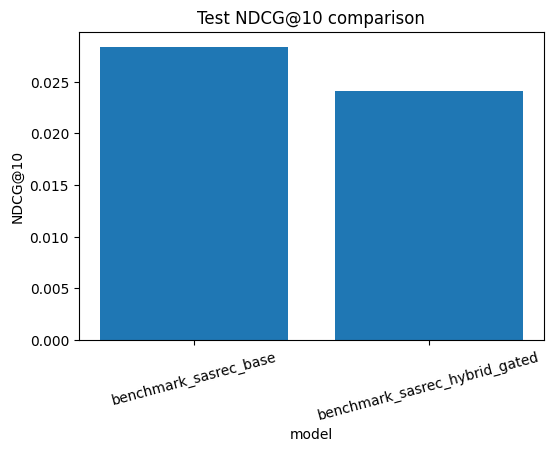

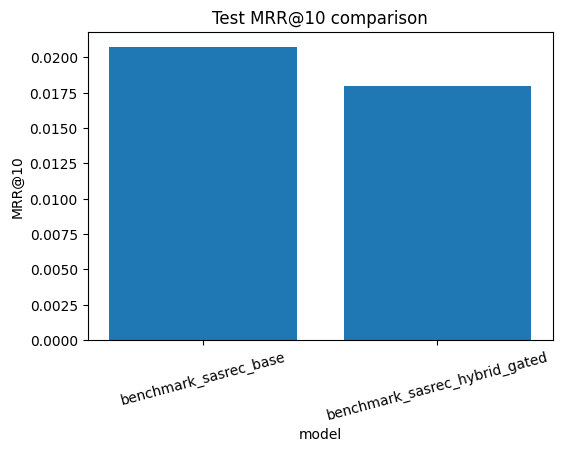

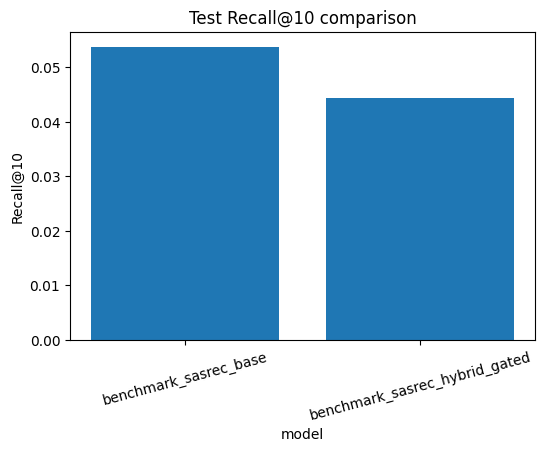

hybrid minus base


,metric,base,hybrid,absolute_gain,relative_gain_pct
0,HR@10,0.053764,0.044291,-0.009473,-17.620199
1,NDCG@10,0.028418,0.024068,-0.004350,-15.307471
2,MRR@10,0.020767,0.017944,-0.002823,-13.593858
3,Recall@10,0.053764,0.044291,-0.009473,-17.620199


In [17]:
metric_cols = ["HR@10", "NDCG@10", "MRR@10", "Recall@10"]

summary_rows = []
if base_test is not None:
    row = base_test.iloc[0][["model"] + metric_cols].to_dict()
    summary_rows.append(row)

if hybrid_test is not None:
    row = hybrid_test.iloc[0][["model"] + metric_cols].to_dict()
    summary_rows.append(row)

if not summary_rows:
    print("No saved test metric files found yet")
else:
    summary_df = pd.DataFrame(summary_rows)
    display(summary_df)

    for metric in metric_cols:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.bar(summary_df["model"], summary_df[metric])
        ax.set_title(f"Test {metric} comparison")
        ax.set_xlabel("model")
        ax.set_ylabel(metric)
        plt.xticks(rotation=15)
        plt.show()

    if len(summary_df) == 2:
        base_row = summary_df.iloc[0]
        hybrid_row = summary_df.iloc[1]
        gain_df = pd.DataFrame({
            "metric": metric_cols,
            "base": [base_row[m] for m in metric_cols],
            "hybrid": [hybrid_row[m] for m in metric_cols],
        })
        gain_df["absolute_gain"] = gain_df["hybrid"] - gain_df["base"]
        gain_df["relative_gain_pct"] = 100 * gain_df["absolute_gain"] / gain_df["base"]
        print("hybrid minus base")
        display(gain_df)


## 17. Optional quick rerun dashboard only

If training is already done, restart the kernel and run only:
- sections 0 to 1
- section 13 to 16

That is enough for result checking and report graphs.
